# Group-level source-space TRF on real OPM-MEG data

The source-space counterpart of `01_opm_sensor_trf.ipynb`: the same cohort and
the same three predictors, but the targets are **parcel timecourses** instead of
sensors — 148 regions of the `aparc.a2009s` surface parcellation.

TRFlearn does no source estimation. The beamforming in step 2 is ordinary MNE
and belongs to the acquisition project; TRFlearn picks the pipeline up at the
point where the data are already in source space.

| Feature | Source | Window (s) |
| --- | --- | --- |
| `saccades` | saccade onsets (CSV) | (-0.2, 0.5) |
| `steering_wheel` | d/dt of the steering wheel | (-2.0, 2.0) |
| `gas_pedal` | d/dt of the accelerator pedal | (-2.0, 2.0) |

Region centroids replace the montage, through one extra call —
`TRFData.set_source_positions`. Everything downstream follows from it:

* `TRFGroup.tfce` gets its spatial adjacency from region **proximity**
  (`statistics.source_adjacency`) rather than from a sensor neighbourhood graph.
  Step 4 swaps that for the **anatomical** graph;
* `to_stc` hands the kernels to MNE's 3D brains.

## Data

Per participant, under `examples/data/` (git-ignored):

```
OPM/<id>/DA2_<id>_meg.fif                       preprocessed OPM recording
OPM/<id>/saccades.csv                           saccade events
source/<id>/..._parcellation_aparc.a2009s_None-lcmv.h5       beamformer weights
source/<id>/..._parcellation_aparc.a2009s_max-power-lcmv.h5  beamformer weights
source/<id>/<id>_processed_chsmag_z_parcellation_aparc.a2009s-fwd.fif
source/<id>/<id>_surface_ico4-src.fif           full surface, for step 6
freesurfer/<id>/label/{lh,rh}.aparc.a2009s.annot    vertex -> region
freesurfer/<id>/surf/{lh,rh}.white                  region borders, for step 4
freesurfer/<id>/surf/{lh,rh}.{inflated,curv}        rendering, for step 6
```

This notebook needs `pip install -e ".[mne]"`, plus `h5io` (reading the `.h5` beamformers) and
`nibabel` (reading FreeSurfer surfaces). Step 6 also needs a 3D backend —
`pip install pyvistaqt PyQt6` (`pyvistaqt` alone ships no Qt binding).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from mne.beamformer import apply_lcmv_raw, read_beamformer

from trflearn import TRFData, TRFGroup
from trflearn import statistics

# MNE reports every beamformer/annotation step; keep only its warnings.
mne.set_log_level("WARNING")


## 1. Configuration


In [2]:
# Works whether the kernel starts in the repo root or in examples/.
HERE = Path.cwd() if Path.cwd().name == "examples" else Path.cwd() / "examples"
DATA_ROOT = HERE / "data" / "OPM"
SOURCE_ROOT = HERE / "data" / "source"
SUBJECTS_DIR = HERE / "data" / "freesurfer"

# One folder per participant.
SUBJECT_IDS = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())

# --- Source model -------------------------------------------------------- #
PARC = "aparc.a2009s"          # surface parcellation (148 regions)
PARC_TAG = f"parcellation_{PARC}"
BAND = "(0.1, 40)"             # band the beamformer weights were built for

# Beamformer orientation. Both sets of weights are on disk:
#   "max-power"  signed scalar -- TRF polarity is interpretable
#   None         magnitude across the three free orientations, so parcel
#                timecourses are non-negative and a kernel's sign means
#                nothing. This is what the acquisition project's script uses.
PICK_ORI = None

LCMV_TEMPLATE = "{sid}_processed_chsmag_z_band" + BAND + f"_{PARC_TAG}_{PICK_ORI}-lcmv.h5"
FWD_TEMPLATE = "{sid}_processed_chsmag_z_" + f"{PARC_TAG}-fwd.fif"
SURF_SRC_TEMPLATE = "{sid}_surface_ico4-src.fif"

# --- Model spec: identical to the sensor-space notebook ------------------- #
FEATURES = ["saccades", "steering_wheel", "gas_pedal"]

DEFAULT_WINDOW = (-0.2, 0.5)
FEATURE_WINDOWS = {
    "saccades": (-0.2, 0.5),
    "steering_wheel": (-2.0, 2.0),
    "gas_pedal": (-2.0, 2.0),
}

# Extra lags fitted on each side of every window and trimmed off the returned
# kernel, so ridge edge-ringing lands on the margin instead of on the estimate.
DELAY_MARGIN = 0.015

REGULARIZATION = 1
N_FOLDS = 5

# With 7 subjects the sign-flip set is exhausted at 2**7 = 128, so this is exact.
N_PERMUTATIONS = 128

# Display-only baseline: the whole window, for every feature.
PLOT_BASELINE = (None, None)

print(f"{len(SUBJECT_IDS)} participants: {', '.join(SUBJECT_IDS)}")

7 participants: 10925, 16432, 17359, 17643, 17734, 18616, 18619


## 2. Per-subject loading

The one step that is *not* TRFlearn's: an LCMV beamformer projects the radial
magnetometers onto the parcellation source space, which carries roughly one
centroid vertex per anatomical label. The result is an `(n_regions, n_times)`
array — an ordinary MNE `Raw` of `misc` channels named after the labels.

Three details decide whether the rows stay aligned with their names, and whether
those names still mean the same thing in the next subject:

* the vertices come from `stc.vertices`, not `src[...]["vertno"]`. When two
  labels resolve to the same centroid the beamformer collapses them, and only
  `stc.vertices` is guaranteed to match the data row for row;
* **one row per label.** A handful of labels catch two source-space vertices, and
  *which* labels differs between participants. Keeping both makes
  `mne.create_info` append `-0`/`-1`, and `S_calcarine-lh` in one subject then
  shares no name with `S_calcarine-lh-0` in the next — so the cohort intersection
  throws the region away. On this cohort that difference is 107 shared regions
  versus 125;
* centroids go to `set_source_positions` as an **array** in column order rather
  than as a name-keyed dict, so nothing depends on name matching.

The bad-segment annotations are carried over from the sensor recording, so
TRFlearn drops those samples from every fold exactly as in sensor space.


In [3]:
def impulse_series(onsets_s: np.ndarray, sfreq: float, n_samples: int) -> np.ndarray:
    """Unit impulses at the given onset times (seconds from recording start)."""
    idx = np.round(np.asarray(onsets_s, dtype=float) * sfreq).astype(int)
    idx = idx[(idx >= 0) & (idx < n_samples)]
    series = np.zeros(n_samples, dtype=np.float64)
    series[idx] = 1.0
    return series


def beamform_to_parcels(meg: mne.io.BaseRaw, subject_id: str):
    """Project sensors onto parcel centroids -> (Raw of regions, centroids)."""
    src_dir = SOURCE_ROOT / subject_id

    filters = read_beamformer(src_dir / LCMV_TEMPLATE.format(sid=subject_id))
    stc = apply_lcmv_raw(meg, filters)

    # The forward is read only for src["rr"] -- the centroid coordinates.
    fwd = mne.read_forward_solution(
        src_dir / FWD_TEMPLATE.format(sid=subject_id), verbose="ERROR")
    src = fwd["src"]
    labels = mne.read_labels_from_annot(
        subject_id, parc=PARC, subjects_dir=SUBJECTS_DIR, verbose="ERROR")

    names, centroids, timecourses = [], [], []
    seen = set()
    for hemi_idx, hemi in enumerate(("lh", "rh")):
        hemi_labels = [lab for lab in labels if lab.hemi == hemi]
        offset = 0 if hemi_idx == 0 else len(stc.vertices[0])
        for row, vertex in enumerate(stc.vertices[hemi_idx]):
            owner = next((lab.name for lab in hemi_labels if vertex in lab.vertices),
                         f"{hemi}_vert{vertex}")
            # One row per label. A few labels catch two source-space vertices, and
            # which ones differs between subjects; keeping both would make
            # mne.create_info append '-0'/'-1' and those names would no longer
            # match the same region in the next subject, so the cohort
            # intersection would drop the region entirely.
            if owner in seen:
                continue
            seen.add(owner)
            names.append(owner)
            centroids.append(src[hemi_idx]["rr"][vertex])
            timecourses.append(stc.data[offset + row])

    info = mne.create_info(names, meg.info["sfreq"], ch_types="misc", verbose="ERROR")
    raw_src = mne.io.RawArray(np.asarray(timecourses), info, verbose="ERROR")
    # Re-referenced to the recording start, which a RawArray has no meas_date for.
    raw_src.set_annotations(mne.Annotations(
        onset=meg.annotations.onset - meg.first_time,
        duration=meg.annotations.duration,
        description=meg.annotations.description))
    return raw_src, np.asarray(centroids)


In [4]:
def load_subject(subject_id: str) -> TRFData:
    """Parcel timecourses and the three predictors of one participant."""
    subject_dir = DATA_ROOT / subject_id
    raw = mne.io.read_raw_fif(subject_dir / f"DA2_{subject_id}_meg.fif",
                              preload=False, verbose="ERROR")
    sfreq = raw.info["sfreq"]

    # Read before picking the sensors, so they survive the pick.
    steering = raw.get_data(picks="Steering")[0]
    gas = raw.get_data(picks="Gas")[0]

    # Radial (Z) magnetometers only -- the set the beamformer was built for.
    picks = [ch for ch, kind in zip(raw.ch_names, raw.get_channel_types())
             if kind == "mag" and ch.endswith(" Z")]
    meg = raw.copy().pick(picks).load_data(verbose="ERROR")
    meg.info.normalize_proj()
    n_samples = meg.n_times

    raw_src, centroids = beamform_to_parcels(meg, subject_id)

    # Onsets in the CSVs are already relative to the file start.
    saccades = pd.read_csv(subject_dir / "saccades.csv")
    features = {
        "saccades": impulse_series(saccades["onset"].to_numpy(), sfreq, n_samples),
        "steering_wheel": np.gradient(steering),
        "gas_pedal": np.gradient(gas),
    }
    features = {name: series.reshape(-1, 1) for name, series in features.items()}

    data = TRFData(features=features, y=raw_src, sample_rate=int(sfreq))
    data.set_source_positions(centroids)      # the one source-space-specific call
    data.create_partitions(n_folds=N_FOLDS)
    return data


## 3. Fit the cohort

Unchanged from sensor space: `TRFGroup` holds the spec once and applies it to
everyone, so the kernels stay comparable. Subjects are matched by region **name**
when the cohort is aggregated, so a participant whose parcellation yields a
slightly different set contributes only the shared regions — see
`group.common_channels`.


In [5]:
group = TRFGroup(
    features=FEATURES,
    cv="pooled",
    default_window=DEFAULT_WINDOW,
    feature_windows=FEATURE_WINDOWS,
    delay_margin=DELAY_MARGIN,
    feature_preprocess="Standardize",
    target_preprocess="Standardize",
    fit_method="fit",
    regularization=REGULARIZATION,
    verbose="warning",     # per-subject status lines would bury the loop below
)

for i, subject_id in enumerate(SUBJECT_IDS, 1):
    print(f"[{i}/{len(SUBJECT_IDS)}] {subject_id}", flush=True)
    group.fit_subject(load_subject(subject_id), subject_id)

print(f"{len(group.common_channels)} regions shared across the cohort")


[1/7] 10925
[2/7] 16432
[3/7] 17359
[4/7] 17643
[5/7] 17734
[6/7] 18616
[7/7] 18619
129 regions shared across the cohort


## 4. Region adjacency

The cluster test needs to know which regions are neighbours, and in source space
there is no montage to read a sensor neighbourhood from. The graph comes from the
cortical surface instead: two regions are neighbours when an edge of the
triangulation joins a vertex of one to a vertex of the other. Hemispheres are
never linked, since no edge crosses between them.

TRFlearn does not read FreeSurfer itself — you load the labels and surfaces and
hand the graph over through `group.spatial_adjacency`. It is built over
`group.common_channels`, **in that order**, which is the channel axis of the
cluster maps.

Skip this step and `tfce` falls back to centroid proximity
(`statistics.source_adjacency`), which needs no surfaces and is the only option
for volume parcellations or virtual electrodes.


In [6]:
template_id = SUBJECT_IDS[0]      # aparc.a2009s names are shared across subjects
labels = mne.read_labels_from_annot(
    template_id, parc=PARC, subjects_dir=SUBJECTS_DIR, verbose="ERROR")
surfaces = {
    hemi: mne.read_surface(SUBJECTS_DIR / template_id / "surf" / f"{hemi}.white")
    for hemi in ("lh", "rh")
}

group.spatial_adjacency = statistics.surface_adjacency(
    group.common_channels, labels, surfaces)


## 5. TFCE over subjects

Same test as in sensor space, over the full `delays × regions` map: the delay
lattice and the region graph from step 4 form the adjacency, so a real effect
can pool evidence over both.

In [7]:
for feature in FEATURES:
    print(feature, flush=True)
    group.tfce(feature, n_permutations=N_PERMUTATIONS, seed=0, n_jobs=-1)


saccades


D:\OneDrive - UBA\TRFlearn\trflearn\group.py:1213: UserWarning: subjects do not share the same channels; aggregating over the 129 common ones and dropping 15: ['G_Ins_lg_and_S_cent_ins-lh', 'G_Ins_lg_and_S_cent_ins-rh', 'G_front_middle-lh', 'G_front_middle-rh', 'G_insular_short-rh', 'G_oc-temp_med-Parahip-lh', 'G_oc-temp_med-Parahip-rh', 'G_pariet_inf-Angular-lh', 'G_pariet_inf-Angular-rh', 'G_subcallosal-rh', 'G_temp_sup-Lateral-lh', 'S_collat_transv_post-lh', 'S_intrapariet_and_P_trans-lh', 'S_orbital_lateral-rh', 'S_temporal_inf-rh']. See TRFGroup.common_channels.
  warnings.warn(


steering_wheel
gas_pedal


## 6. Plots

`to_stc` paints every vertex of a label with its region's coefficient, giving the
flat, uniformly coloured parcels that make a parcellation figure readable as
one. TRFlearn stops there and hands back a plain `mne.SourceEstimate`: the
rendering is MNE's, with all of its arguments available and no 3D backend pulled
in unless this cell runs.

Topography-based figures (`plot_joint`, `plot_features`, topomaps) are
unavailable in source space: they interpolate onto a head surface, which parcel
centroids do not lie on.

The `labels` and `template_id` from step 4 are reused, which is what keeps the
parcellation and the surface it is painted on the same subject's.

With `PICK_ORI = None` a kernel's sign carries no meaning (see step 1), so the
colour scale is one-sided: `lims` shows magnitude from the 95th percentile up,
on a sequential colormap, instead of the diverging `pos_lims` scale.

The 3D window is screenshotted and embedded, then closed. A live PyVista window
is not stored in the saved notebook, so the figure would be missing for anyone
reading the file later.


### Plot evoked response at 100 ms

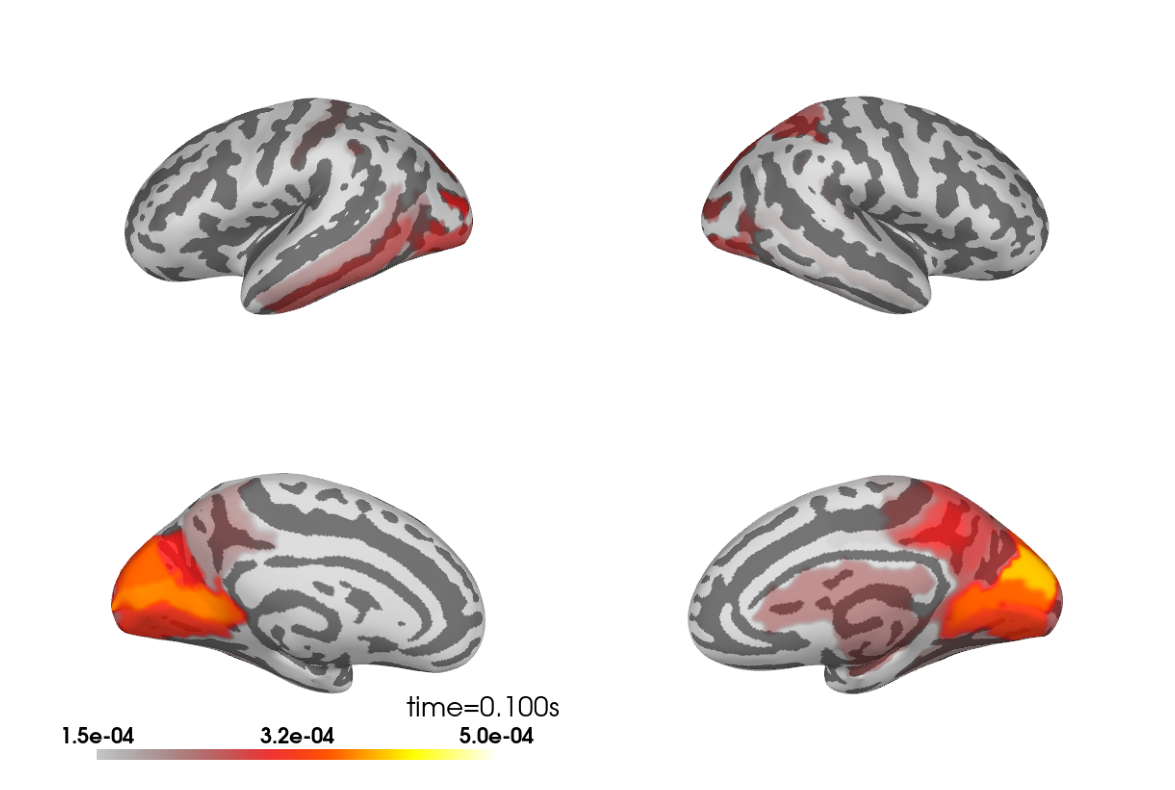

In [8]:
group.plot_baseline = PLOT_BASELINE

src_full = mne.read_source_spaces(
    SOURCE_ROOT / template_id / SURF_SRC_TEMPLATE.format(sid=template_id),
    verbose="ERROR")

stc = group.to_stc("saccades", labels, src_full)

# Three labels instead of MNE's eight: the default crowd into each other at
# this magnitude (~1e-4).
COLORBAR = dict(colorbar_kwargs=dict(n_labels=3, fmt="%.1e"))

brain = stc.plot(
    clim=dict(kind="percent", lims=[95, 99, 99.5]),
    subject=template_id, subjects_dir=SUBJECTS_DIR, hemi="split",
    views=["lateral", "medial"], surface="inflated", initial_time=0.1,
    time_unit="s", background="white", size=(1200, 800),
    time_viewer=False, show_traces=False, add_data_kwargs=COLORBAR,
    verbose="ERROR")

# Grab a still and close the render window: a live 3D window is not saved with
# the notebook, so the figure would be lost to anyone reading it later.
screenshot = brain.screenshot()
brain.close()

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(screenshot)
ax.set_axis_off()
fig.tight_layout()


### Plot ocular artifact at 0 ms

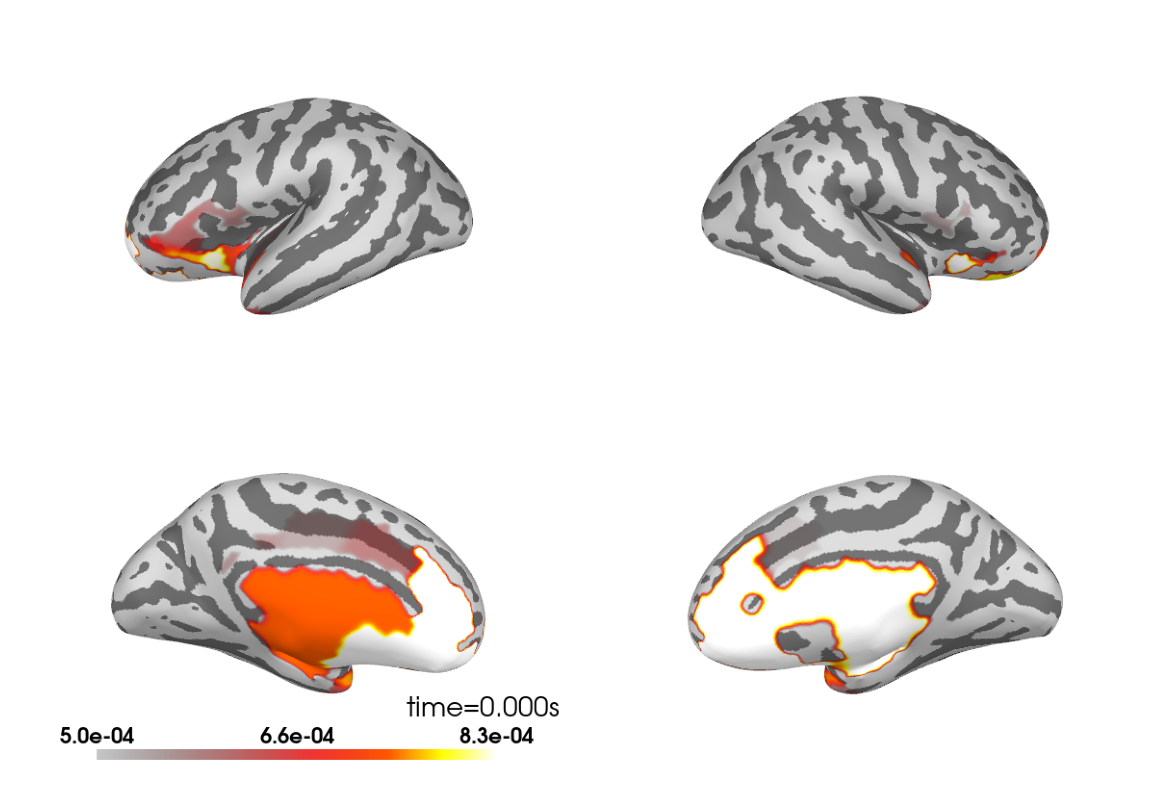

In [9]:
brain = stc.plot(
    clim=dict(kind="percent", lims=[99.5, 99.9, 99.95]),
    subject=template_id, subjects_dir=SUBJECTS_DIR, hemi="split",
    views=["lateral", "medial"], surface="inflated", initial_time=0,
    time_unit="s", background="white", size=(1200, 800),
    time_viewer=False, show_traces=False, add_data_kwargs=COLORBAR,
    verbose="ERROR")

screenshot = brain.screenshot()
brain.close()

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(screenshot)
ax.set_axis_off()
fig.tight_layout()
